In [ ]:
!pip install -q kagglehub spacy pandas matplotlib

In [ ]:
import os
import pandas as pd
import spacy
import matplotlib.pyplot as plt

from spacy.matcher import Matcher
from spacy import displacy

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")

print("Path to dataset files:", path)

100%|██████████| 960k/960k [00:00<00:00, 1.35MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1


In [ ]:
print("Files in dataset folder:")

for file in os.listdir(path):
    print(file)

Files in dataset folder:
metadata
test.txt
valid.txt
train.txt


In [ ]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1/metadata
/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1/test.txt
/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1/valid.txt
/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1/train.txt


In [ ]:
train_file = os.path.join(path, "train.txt")

with open(train_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Number of lines:", len(lines))
print("\nFirst 30 lines:\n")

for line in lines[:30]:
    print(line.strip())

Number of lines: 219554

First 30 lines:

-DOCSTART- -X- -X- O

EU NNP B-NP B-ORG
rejects VBZ B-VP O
German JJ B-NP B-MISC
call NN I-NP O
to TO B-VP O
boycott VB I-VP O
British JJ B-NP B-MISC
lamb NN I-NP O
. . O O

Peter NNP B-NP B-PER
Blackburn NNP I-NP I-PER

BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O

The DT B-NP O
European NNP I-NP B-ORG
Commission NNP I-NP I-ORG
said VBD B-VP O
on IN B-PP O
Thursday NNP B-NP O
it PRP B-NP O
disagreed VBD B-VP O
with IN B-PP O
German JJ B-NP B-MISC
advice NN I-NP O
to TO B-PP O


In [ ]:
sentences = []
tokens = []
labels = []

for line in lines:
    line = line.strip()

    # Empty line = end of sentence
    if not line:
        if tokens:
            sentences.append((tokens, labels))
            tokens = []
            labels = []
        continue

    parts = line.split()

    if len(parts) >= 2:
        token = parts[0]
        label = parts[-1]

        tokens.append(token)
        labels.append(label)

# Add last sentence if needed
if tokens:
    sentences.append((tokens, labels))

print("Number of sentences:", len(sentences))

print("\nExample sentence:")
print(sentences[0])

Number of sentences: 14987

Example sentence:
(['-DOCSTART-'], ['O'])


In [ ]:
data = []

for tokens, labels in sentences:
    data.append({
        "tokens": tokens,
        "labels": labels,
        "text": " ".join(tokens)
    })

df = pd.DataFrame(data)

print(df.head())
print("\nDataset shape:", df.shape)

                                              tokens  \
0                                       [-DOCSTART-]   
1  [EU, rejects, German, call, to, boycott, Briti...   
2                                 [Peter, Blackburn]   
3                             [BRUSSELS, 1996-08-22]   
4  [The, European, Commission, said, on, Thursday...   

                                              labels  \
0                                                [O]   
1          [B-ORG, O, B-MISC, O, O, O, B-MISC, O, O]   
2                                     [B-PER, I-PER]   
3                                         [B-LOC, O]   
4  [O, B-ORG, I-ORG, O, O, O, O, O, O, B-MISC, O,...   

                                                text  
0                                         -DOCSTART-  
1   EU rejects German call to boycott British lamb .  
2                                    Peter Blackburn  
3                                BRUSSELS 1996-08-22  
4  The European Commission said on Thursday it di..

In [ ]:
print("Number of articles/sentences:", len(df))

print("\nExample text:")
print(df["text"].iloc[0])

print("\nExample labels:")
print(df["labels"].iloc[0])

Number of articles/sentences: 14987

Example text:
-DOCSTART-

Example labels:
['O']


In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully!")

spaCy model loaded successfully!


In [ ]:
sample_text = df["text"].iloc[1]

doc = nlp(sample_text)

print("Text:")
print(sample_text)

print("\nEntities:")

for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Text:
EU rejects German call to boycott British lamb .

Entities:
EU -> ORG
German -> NORP
British -> NORP


In [ ]:
entity_data = []

for ent in doc.ents:
    entity_data.append({
        "Entity": ent.text,
        "Label": ent.label_
    })

entity_df = pd.DataFrame(entity_data)

entity_df

,Entity,Label
0,EU,ORG
1,German,NORP
2,British,NORP


In [ ]:
all_entities = []

for text in df["text"].head(1000):

    doc = nlp(text)

    for ent in doc.ents:
        all_entities.append({
            "Entity": ent.text,
            "Label": ent.label_
        })

entities_df = pd.DataFrame(all_entities)

print(entities_df.head())
print("\nTotal extracted entities:", len(entities_df))

            Entity   Label
0               EU     ORG
1           German    NORP
2          British    NORP
3  Peter Blackburn  PERSON
4         BRUSSELS     GPE

Total extracted entities: 2574


In [ ]:
entity_counts = entities_df["Label"].value_counts()

print(entity_counts)

Label
GPE            567
PERSON         543
CARDINAL       460
DATE           329
ORG            319
NORP           138
ORDINAL         95
MONEY           37
PERCENT         18
TIME            14
EVENT           12
LOC             11
QUANTITY        10
FAC              8
PRODUCT          7
LAW              4
LANGUAGE         1
WORK_OF_ART      1
Name: count, dtype: int64


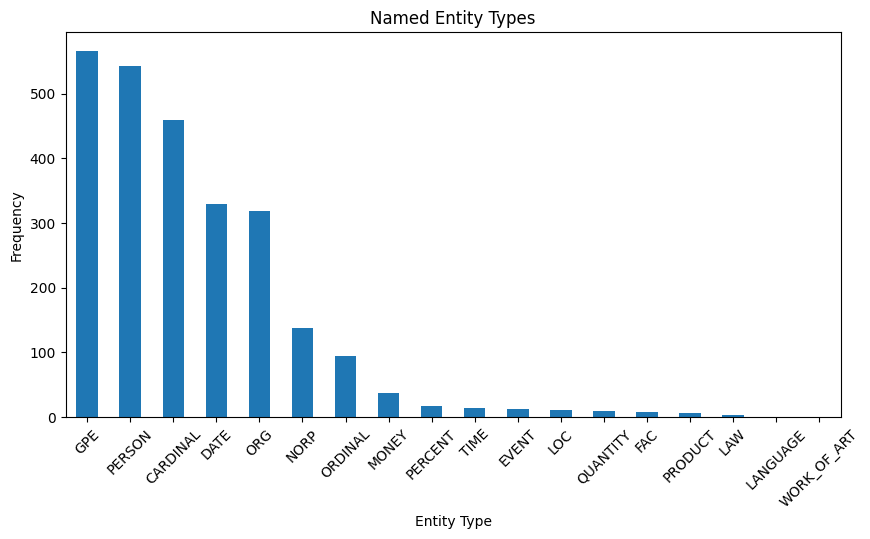

In [ ]:
plt.figure(figsize=(10, 5))

entity_counts.plot(kind="bar")

plt.title("Named Entity Types")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [ ]:
matcher = Matcher(nlp.vocab)

pattern = [
    {"IS_TITLE": True},
    {"LOWER": {"IN": ["inc", "corp", "ltd", "company"]}}
]

matcher.add("ORG_PATTERN", [pattern])

In [ ]:
rule_text = """
Apple Inc announced a new product.
Microsoft Corp opened a new office.
Google Company released a new update.
"""

doc = nlp(rule_text)

matches = matcher(doc)

print("Rule-based entities:")

for match_id, start, end in matches:
    span = doc[start:end]
    print(span.text, "-> ORG")

Rule-based entities:
Apple Inc -> ORG
Microsoft Corp -> ORG
Google Company -> ORG


In [ ]:
text = """
Microsoft Corp announced a new project in London.
John Smith joined the company in 2025.
"""

doc = nlp(text)

print("MODEL-BASED NER")
print("-" * 30)

for ent in doc.ents:
    print(ent.text, "->", ent.label_)

print("\nRULE-BASED NER")
print("-" * 30)

matches = matcher(doc)

for match_id, start, end in matches:
    span = doc[start:end]
    print(span.text, "-> ORG")

MODEL-BASED NER
------------------------------
Microsoft Corp -> ORG
London -> GPE
John Smith -> PERSON
2025 -> DATE

RULE-BASED NER
------------------------------
Microsoft Corp -> ORG


In [ ]:
text = df["text"].iloc[1]

doc = nlp(text)

displacy.render(
    doc,
    style="ent",
    jupyter=True
)

In [ ]:
text = """
Barack Obama visited London and met with Microsoft executives.
The meeting took place in the United States in 2024.
"""

doc = nlp(text)

displacy.render(
    doc,
    style="ent",
    jupyter=True
)

In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 33.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp_sm = spacy.load("en_core_web_sm")
nlp_md = spacy.load("en_core_web_md")

In [ ]:
comparison_text = """
Apple CEO Tim Cook visited London to meet with British officials.
Microsoft announced a new technology center in New York.
"""

doc_sm = nlp_sm(comparison_text)
doc_md = nlp_md(comparison_text)

print("en_core_web_sm:")
for ent in doc_sm.ents:
    print(ent.text, "->", ent.label_)

print("\n" + "=" * 50)

print("en_core_web_md:")
for ent in doc_md.ents:
    print(ent.text, "->", ent.label_)

en_core_web_sm:
Apple -> ORG
Tim Cook -> PERSON
London -> GPE
British -> NORP
Microsoft -> ORG
New York -> GPE

en_core_web_md:
Apple -> ORG
Tim Cook -> PERSON
London -> GPE
British -> NORP
Microsoft -> ORG
New York -> GPE


In [ ]:
sm_entities = [(ent.text, ent.label_) for ent in doc_sm.ents]
md_entities = [(ent.text, ent.label_) for ent in doc_md.ents]

print("SM Model Entities:")
print(sm_entities)

print("\nMD Model Entities:")
print(md_entities)

SM Model Entities:
[('Apple', 'ORG'), ('Tim Cook', 'PERSON'), ('London', 'GPE'), ('British', 'NORP'), ('Microsoft', 'ORG'), ('New York', 'GPE')]

MD Model Entities:
[('Apple', 'ORG'), ('Tim Cook', 'PERSON'), ('London', 'GPE'), ('British', 'NORP'), ('Microsoft', 'ORG'), ('New York', 'GPE')]


In [ ]:
top_entities = (
    entities_df["Entity"]
    .value_counts()
    .head(20)
)

print(top_entities)

Entity
1996-08-22    48
Thursday      48
1             35
U.S.          31
6             26
Spain         25
Australia     24
Wednesday     22
Sweden        20
2             18
first         17
Germany       17
Israel        16
two           16
7             16
three         15
4             15
France        15
Iraq          15
China         14
Name: count, dtype: int64


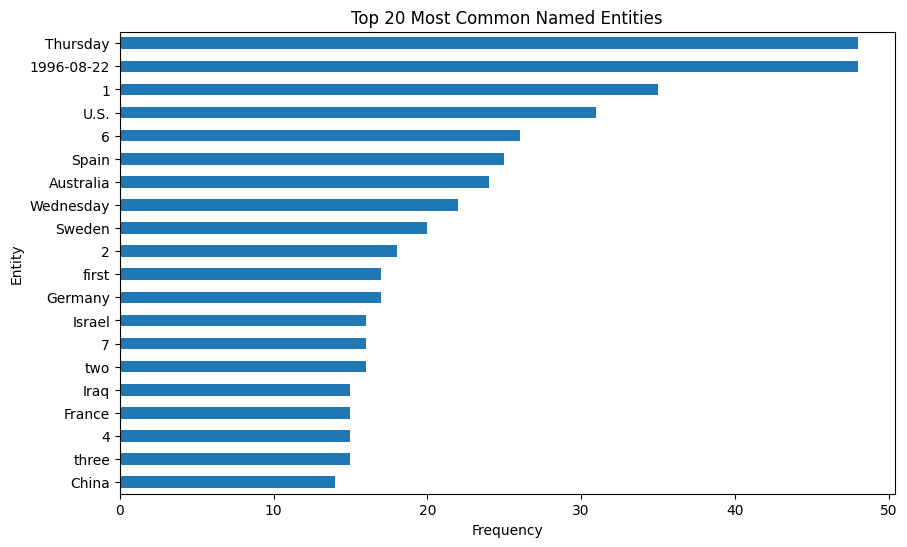

In [ ]:
plt.figure(figsize=(10, 6))

top_entities.sort_values().plot(kind="barh")

plt.title("Top 20 Most Common Named Entities")
plt.xlabel("Frequency")
plt.ylabel("Entity")

plt.show()

In [ ]:
print("========== NER PROJECT SUMMARY ==========")

print("Number of sentences:", len(df))
print("Entities extracted:", len(entities_df))

print("\nEntity Types:")
print(entity_counts)

print("\nMost Common Entities:")
print(top_entities)

========== NER PROJECT SUMMARY ==========
Number of sentences: 14987
Entities extracted: 2574

Entity Types:
Label
GPE            567
PERSON         543
CARDINAL       460
DATE           329
ORG            319
NORP           138
ORDINAL         95
MONEY           37
PERCENT         18
TIME            14
EVENT           12
LOC             11
QUANTITY        10
FAC              8
PRODUCT          7
LAW              4
LANGUAGE         1
WORK_OF_ART      1
Name: count, dtype: int64

Most Common Entities:
Entity
1996-08-22    48
Thursday      48
1             35
U.S.          31
6             26
Spain         25
Australia     24
Wednesday     22
Sweden        20
2             18
first         17
Germany       17
Israel        16
two           16
7             16
three         15
4             15
France        15
Iraq          15
China         14
Name: count, dtype: int64
